#  G6 FOOD PRICE PREDICTION


---

# 1. Business understanding

## 1.1 Business Overview

Over the last 24 months, the Kenyan market has been characterized by extreme volatility in the prices of essential food items, ranging from fresh produce like tomatoes and avocados to staples such as maize, beans, and flour. These unpredictable fluctuations create a destabilizing cycle for both consumers and producers, as the market rapidly oscillates between wasteful surpluses and 
acute shortages.
 
This project seeks to mitigate these imbalances by utilizing time-series forecasting to provide reliable price predictions. By delivering actionable insights—such as forecasting the value of a 90kg bag of maize half a year into the future—the model empowers farmers in regions like Uasin Gishu to make informed, data-driven decisions on whether to maintain current crop cycles or pivot to more viable alternatives.

## 1.2 Stakeholders
• Consumers: To aid in household budgeting and long-term food procurement planning.

• Farmers & Saccos: To determine optimal planting cycles and market entry timing to 
maximize profit. 

• Government Agencies (Ministry of Agriculture/NCPB): To inform policy interventions such as 
food subsidies or strategic grain reserve management. 

• General Insurance Providers: For potential use in agricultural insurance risk assessment and 
index-based weather insurance.

## 1.3 Business Objectives
### Main Objective:
Develop and deploy a multivariate machine learning model to forecast the prices of key commodities (Maize, Milk, Beans) across different Kenyan markets
### Specific objective:
Integrate external causal factors—specifically rainfall and fuel prices—to enhance the model's predictive accuracy regarding price shocks

## 1.4 Project shortcomings
• Direct Insurance Underwriting: While insights benefit insurers, direct claims management is beyond the scope. 

• Logistics Management: The project does not automate the physical supply chain or transport of goods.

# 2. Data Understanding

## 2.1 Data Sources:
The project will leverage three primary online data sources to ensure a comprehensive feature set:

• WFP Food Prices (HDX): Historical monthly price data for various commodities and markets across Kenya.

• CHIRPS Rainfall Data (Google Earth Engine/HDX): Historical precipitation levels to track climate-related supply shifts. 

• EPRA Fuel Prices: Historical diesel prices to account for transportation and production costs.

## 2.2 Target and Predictors:
• Target: The future price of a specific commodity (e.g., KES per 90kg bag of maize).

• Predictors:

o Time Indicators: Month, year, and seasonality markers. 

o Market Metadata: Region, market name, and commodity type.

o External Features: Monthly average rainfall (mm) and Diesel retail prices (KES)

# 3. Workflow Phases: 
1. Data Exploration
2. Data Preparation & Merging
3. Exploratory Data Analysis (EDA)
4. Feature Engineering & Lag Creation
5. Modelling (Linear Regression → Gradient Boosted Trees)
6. Evaluation
7. Prediction Interface


##  4. Importing libraries

In [69]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# ── Modelling ───────────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── Display settings ────────────────────────────────────────────────────────
#pd.set_option('display.max_columns', 30)
#pd.set_option('display.float_format', '{:.2f}'.format)


---
##  4.1.  Loading the data

Three independent datasets must be loaded and understood before merging.

### 4a. WFP Food Prices (Target Dataset)

In [70]:
# Load WFP Food Prices 
wfp = pd.read_csv('food_prices_ken.csv', parse_dates=['date'])

print(f'Shape: {wfp.shape}')
print(f'Date range: {wfp["date"].min().date()} → {wfp["date"].max().date()}')
print(f'Unique counties (admin2): {wfp["admin2"].nunique()}')
print(f'Unique commodities: {wfp["commodity"].nunique()}')
print()
wfp.head()

Shape: (19005, 16)
Date range: 2006-01-15 → 2026-03-15
Unique counties (admin2): 27
Unique commodities: 51



,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,16.13,0.22
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47
3,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,3246.00,45.15
4,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.00,0.24


In [71]:
# Summary statistics 
print('=== Missing Values ===')
print(wfp.isnull().sum())
print()
print('=== Numeric Summary ===')
wfp[['price', 'usdprice']].describe()

=== Missing Values ===
date             0
admin1          39
admin2          39
market           0
market_id        0
latitude        39
longitude       39
category         0
commodity        0
commodity_id     0
unit             0
priceflag        0
pricetype        0
currency         0
price            0
usdprice         0
dtype: int64

=== Numeric Summary ===


,price,usdprice
count,19005.00,19005.00
mean,1327.82,12.13
std,2609.37,23.11
min,5.00,0.04
25%,67.00,0.60
50%,133.00,1.06
75%,1105.00,10.36
max,19800.00,184.82


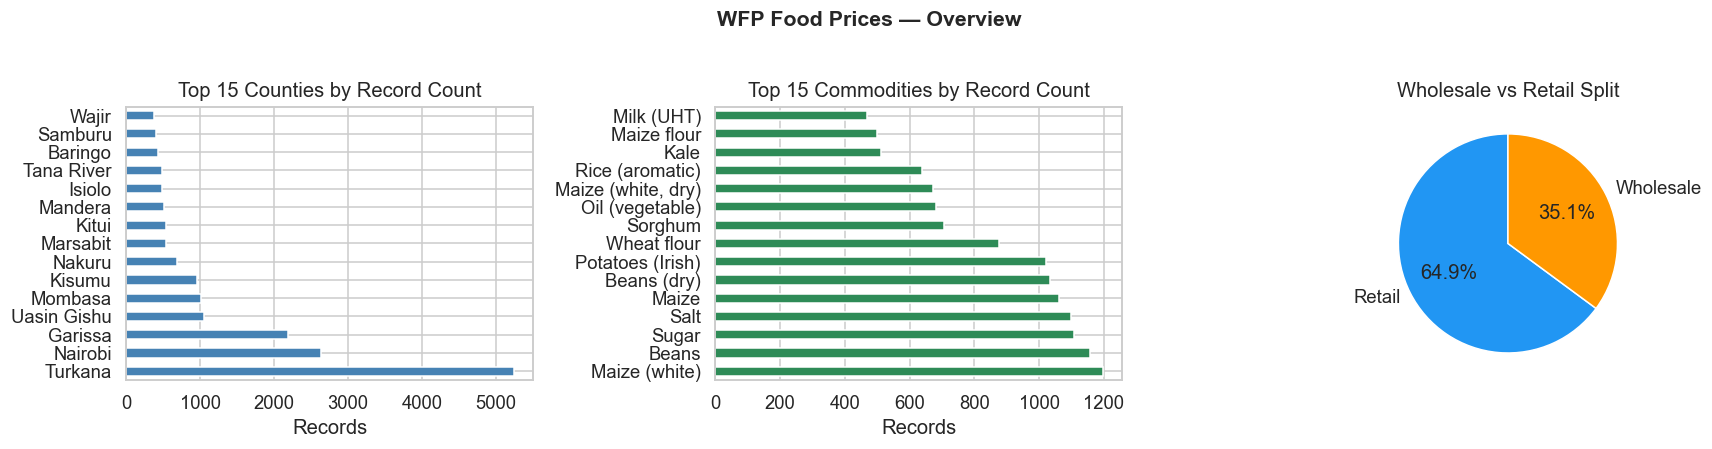

In [72]:
#  Key field distributions 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Records per county
wfp['admin2'].value_counts().head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Counties by Record Count')
axes[0].set_xlabel('Records')

# Records per commodity (top 15)
wfp['commodity'].value_counts().head(15).plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Top 15 Commodities by Record Count')
axes[1].set_xlabel('Records')

# Price type split
wfp['pricetype'].value_counts().plot(kind='pie', ax=axes[2], autopct='%1.1f%%',
                                      colors=['#2196F3', '#FF9800'], startangle=90)
axes[2].set_title('Wholesale vs Retail Split')
axes[2].set_ylabel('')

plt.suptitle('WFP Food Prices — Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4b. CHIRPS Rainfall Data

In [73]:
# Load Rainfall Data 
rain = pd.read_csv('ken-rainfall-subnat-full.csv', parse_dates=['date'])

print(f'Shape: {rain.shape}')
print(f'Date range: {rain["date"].min().date()} → {rain["date"].max().date()}')
print(f'Admin levels: {rain["adm_level"].unique()}')
print(f'Unique PCODEs: {rain["PCODE"].nunique()}')
print()
rain.head()

Shape: (132273, 15)
Date range: 1981-01-01 → 2026-05-01
Admin levels: [1 2]
Unique PCODEs: 81



,date,adm_level,adm_id,PCODE,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version
0,1981-01-01,1,51325,KE019,427.00,7.37,15.76,nan,nan,nan,nan,59.60,nan,nan,final
1,1981-01-11,1,51325,KE019,427.00,4.33,19.29,nan,nan,nan,nan,38.38,nan,nan,final
2,1981-01-21,1,51325,KE019,427.00,5.57,16.27,17.27,51.32,nan,nan,49.70,39.54,nan,final
3,1981-02-01,1,51325,KE019,427.00,5.88,12.72,15.78,48.28,nan,nan,61.42,39.00,nan,final
4,1981-02-11,1,51325,KE019,427.00,17.18,18.77,28.63,47.75,nan,nan,93.32,63.75,nan,final


In [74]:
# Rainfall fields glossary 
glossary = {
    'rfh':     'Rainfall height for the current dekad (10-day period) in mm',
    'rfh_avg': 'Historical average rainfall for this dekad',
    'r1h':     'Cumulative rainfall over the past 1 month (mm)',
    'r1h_avg': 'Historical 1-month average rainfall',
    'r3h':     'Cumulative rainfall over the past 3 months (mm)',
    'r3h_avg': 'Historical 3-month average rainfall',
    'rfq':     'Rainfall anomaly (current vs. average, %) — dekadal',
    'r1q':     'Rainfall anomaly — 1-month rolling',
    'r3q':     'Rainfall anomaly — 3-month rolling',
}
print('CHIRPS Rainfall Feature ')
print('=' * 55)
for k, v in glossary.items():
    print(f'  {k:<10} {v}')

CHIRPS Rainfall Feature 
  rfh        Rainfall height for the current dekad (10-day period) in mm
  rfh_avg    Historical average rainfall for this dekad
  r1h        Cumulative rainfall over the past 1 month (mm)
  r1h_avg    Historical 1-month average rainfall
  r3h        Cumulative rainfall over the past 3 months (mm)
  r3h_avg    Historical 3-month average rainfall
  rfq        Rainfall anomaly (current vs. average, %) — dekadal
  r1q        Rainfall anomaly — 1-month rolling
  r3q        Rainfall anomaly — 3-month rolling


In [75]:
print('Missing values in rainfall data:')
print(rain.isnull().sum())
print()
print('County-level PCODEs (adm_level = 1):')
print(rain[rain['adm_level']==1]['PCODE'].unique())

Missing values in rainfall data:
date           0
adm_level      0
adm_id         0
PCODE          0
n_pixels       0
rfh            0
rfh_avg        0
r1h          162
r1h_avg      162
r3h          648
r3h_avg      648
rfq            0
r1q          162
r3q          648
version        0
dtype: int64

County-level PCODEs (adm_level = 1):
['KE019' 'KE004' 'KE010' 'KE047' 'KE008' 'KE043' 'KE023' 'KE037']


### 4c. EPRA Fuel Prices

In [76]:
# Load Fuel Prices 
fuel = pd.read_csv('Pump Prices  Energy and Petroleum Regulatory Authority.csv')

# Standardise date — multiple formats exist in this dataset
fuel['date'] = pd.to_datetime(fuel['Date'], dayfirst=True)
fuel = fuel.drop(columns=['Date']).sort_values('date').reset_index(drop=True)

print(f'Shape: {fuel.shape}')
print(f'Date range: {fuel["date"].min().date()} → {fuel["date"].max().date()}')
print(f'Towns covered: {fuel["Town"].unique()}')
print()
fuel.head(8)

Shape: (197, 5)


Date range: 2010-01-15 → 2026-04-16
Towns covered: ['Nairobi']



,Town,Super (PMS),Diesel (AGO),Kerosene (IK),date
0,Nairobi,98.50,89.20,80.10,2010-01-15
1,Nairobi,99.80,90.50,81.40,2010-02-15
2,Nairobi,88.52,76.90,61.35,2010-03-15
3,Nairobi,90.64,79.90,61.80,2010-04-15
4,Nairobi,103.70,94.40,85.30,2010-05-15
5,Nairobi,105.00,95.70,86.60,2010-06-15
6,Nairobi,106.30,97.00,87.90,2010-07-15
7,Nairobi,107.60,98.30,89.20,2010-08-15


plot the fuel price trend across the years

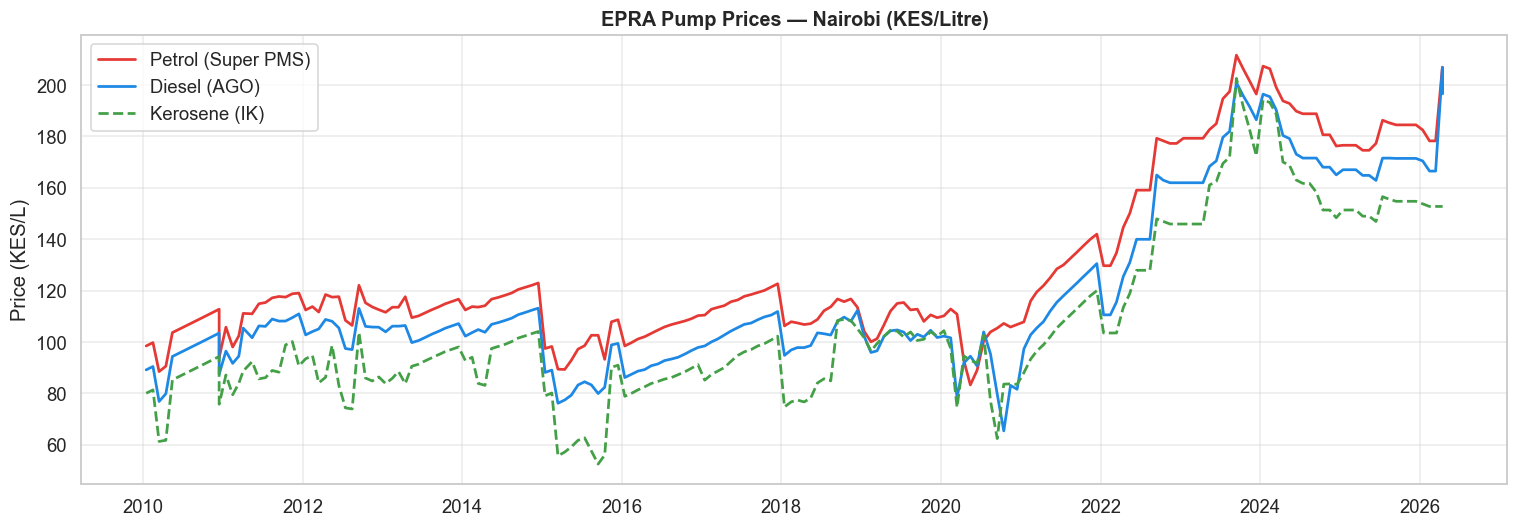

In [77]:
# Plot fuel price trends 
nairobi_fuel = fuel[fuel['Town'] == 'Nairobi'].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(nairobi_fuel['date'], nairobi_fuel['Super (PMS)'],  label='Petrol (Super PMS)',  color='#E53935', lw=1.8)
ax.plot(nairobi_fuel['date'], nairobi_fuel['Diesel (AGO)'], label='Diesel (AGO)',         color='#1E88E5', lw=1.8)
ax.plot(nairobi_fuel['date'], nairobi_fuel['Kerosene (IK)'],label='Kerosene (IK)',        color='#43A047', lw=1.8, ls='--')
ax.set_title('EPRA Pump Prices — Nairobi (KES/Litre)', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (KES/L)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

---
##  4.2 Data Preparation & Merging

### 4.2a. Standardise Dates to Monthly (YYYY-MM-DD)

Step 1: Normalise all dates to month-start

In [78]:
# WFP — already monthly
wfp['date_month'] = wfp['date'].dt.to_period('M').dt.to_timestamp()

# Fuel — irregular dates; take median monthly price
fuel['date_month'] = fuel['date'].dt.to_period('M').dt.to_timestamp()
fuel_monthly = (
    fuel[fuel['Town'] == 'Nairobi']
    .groupby('date_month')[['Super (PMS)', 'Diesel (AGO)', 'Kerosene (IK)']]
    .median()
    .reset_index()
)
fuel_monthly.columns = ['date_month', 'petrol_kes', 'diesel_kes', 'kerosene_kes']
print('Fuel monthly shape:', fuel_monthly.shape)
fuel_monthly.tail()

Fuel monthly shape: (195, 4)


,date_month,petrol_kes,diesel_kes,kerosene_kes
190,2025-12-01,184.52,171.47,154.78
191,2026-01-01,182.52,170.47,153.78
192,2026-02-01,178.28,166.54,152.78
193,2026-03-01,178.28,166.54,152.78
194,2026-04-01,202.28,201.74,152.78


### 4.2b. Rainfall — Aggregate Dekadal → Monthly

In [79]:
# PCODE → County name mapping 
# Using Kenya official PCODE standard (47 counties)
# Only counties covered by EPRA/WFP data need mapping
pcode_county_map = {
    # Standard 2-char PCODEs (adm_level 1 in CHIRPS)
    'KE001': 'Mombasa',     'KE002': 'Kwale',       'KE003': 'Kilifi',
    'KE004': 'Tana River',  'KE005': 'Lamu',         'KE006': 'Taita Taveta',
    'KE007': 'Garissa',     'KE008': 'Wajir',        'KE009': 'Mandera',
    'KE010': 'Marsabit',    'KE011': 'Isiolo',       'KE012': 'Meru',
    'KE013': 'Tharaka Nithi','KE014': 'Embu',        'KE015': 'Kitui',
    'KE016': 'Machakos',    'KE017': 'Makueni',      'KE018': 'Nyandarua',
    'KE019': 'Nyeri',       'KE020': 'Kirinyaga',    'KE021': "Muranga",
    'KE022': 'Kiambu',      'KE023': 'Turkana',      'KE024': 'West Pokot',
    'KE025': 'Samburu',     'KE026': 'Trans Nzoia',  'KE027': 'Uasin Gishu',
    'KE028': 'Elgeyo Marakwet','KE029': 'Nandi',     'KE030': 'Baringo',
    'KE031': 'Laikipia',    'KE032': 'Nakuru',       'KE033': 'Narok',
    'KE034': 'Kajiado',     'KE035': 'Kericho',      'KE036': 'Bomet',
    'KE037': 'Kakamega',    'KE038': 'Vihiga',       'KE039': 'Bungoma',
    'KE040': 'Busia',       'KE041': 'Siaya',        'KE042': 'Kisumu',
    'KE043': 'Homa Bay',    'KE044': 'Migori',       'KE045': 'Kisii',
    'KE046': 'Nyamira',     'KE047': 'Nairobi',
}

# For sub-county PCODEs like 'KE022122', the parent county is the first 5 chars
def pcode_to_county(pcode):
    key = pcode[:5]  # e.g. 'KE022' from 'KE022122'
    return pcode_county_map.get(key, None)

rain['county'] = rain['PCODE'].apply(pcode_to_county)
print('PCODEs with no county mapping:', rain[rain['county'].isna()]['PCODE'].unique()[:10])
rain = rain[rain['county'].notna()].copy()
print(f'Rainfall rows after mapping: {len(rain)}')

PCODEs with no county mapping: []
Rainfall rows after mapping: 132273


In [80]:
# Aggregate dekadal rainfall → monthly per county 
rain['date_month'] = rain['date'].dt.to_period('M').dt.to_timestamp()

rain_monthly = (
    rain.groupby(['date_month', 'county'])
    .agg(
        rainfall_mm   = ('rfh',     'sum'),    # total mm for the month
        rainfall_avg  = ('rfh_avg', 'mean'),   # historical monthly average
        r1h           = ('r1h',     'last'),   # 1-month rolling (last dekad is most recent)
        r3h           = ('r3h',     'last'),   # 3-month rolling
        rainfall_anom = ('rfq',     'mean'),   # anomaly %
    )
    .reset_index()
)

print('Monthly rainfall shape:', rain_monthly.shape)
print('Counties in rainfall:', sorted(rain_monthly['county'].unique()))
rain_monthly.head()

Monthly rainfall shape: (25615, 7)
Counties in rainfall: ['Baringo', 'Bomet', 'Bungoma', 'Busia', 'Elgeyo Marakwet', 'Embu', 'Garissa', 'Homa Bay', 'Isiolo', 'Kajiado', 'Kakamega', 'Kericho', 'Kiambu', 'Kilifi', 'Kirinyaga', 'Kisii', 'Kisumu', 'Kitui', 'Kwale', 'Laikipia', 'Lamu', 'Machakos', 'Makueni', 'Mandera', 'Marsabit', 'Meru', 'Migori', 'Mombasa', 'Muranga', 'Nairobi', 'Nakuru', 'Nandi', 'Narok', 'Nyamira', 'Nyandarua', 'Nyeri', 'Samburu', 'Siaya', 'Taita Taveta', 'Tana River', 'Tharaka Nithi', 'Trans Nzoia', 'Turkana', 'Uasin Gishu', 'Vihiga', 'Wajir', 'West Pokot']


,date_month,county,rainfall_mm,rainfall_avg,r1h,r3h,rainfall_anom
0,1981-01-01,Baringo,13.32,9.96,7.42,nan,49.89
1,1981-01-01,Bomet,65.77,27.82,29.91,nan,50.74
2,1981-01-01,Bungoma,36.53,14.97,15.10,nan,56.07
3,1981-01-01,Busia,56.74,19.63,28.00,nan,59.20
4,1981-01-01,Elgeyo Marakwet,18.06,12.63,8.30,nan,47.33


### 4.2c. WFP — Filter & Focus on Key Commodities

In [81]:
# Focus on Retail prices for key staples 
# (Retail is most relevant to consumers & farmers)
KEY_COMMODITIES = [
    'Maize (white)', 'Maize', 'Beans (dry)', 'Beans',
    'Milk (cow, pasteurized)', 'Milk (cow, fresh)',
    'Maize flour', 'Wheat flour'
]

wfp_filtered = wfp[
    (wfp['commodity'].isin(KEY_COMMODITIES)) &
    (wfp['pricetype'] == 'Retail')
].copy()

# Consolidate commodity names for easier modelling
commodity_map = {
    'Maize (white)': 'Maize', 'Maize': 'Maize',
    'Beans (dry)':   'Beans', 'Beans': 'Beans',
    'Milk (cow, pasteurized)': 'Milk', 'Milk (cow, fresh)': 'Milk',
    'Maize flour': 'Maize Flour', 'Wheat flour': 'Wheat Flour'
}
wfp_filtered['commodity_clean'] = wfp_filtered['commodity'].map(commodity_map)

print(f'Filtered WFP shape: {wfp_filtered.shape}')
print('Commodity distribution:')
print(wfp_filtered['commodity_clean'].value_counts())

Filtered WFP shape: (4140, 18)
Commodity distribution:
Maize          1179
Beans          1094
Wheat Flour     875
Maize Flour     500
Milk            492
Name: commodity_clean, dtype: int64


In [82]:
# ── Monthly average price per county-commodity ───────────────────────────
wfp_monthly = (
    wfp_filtered.groupby(['date_month', 'admin2', 'commodity_clean'])
    .agg(
        price    = ('price',    'mean'),
        usdprice = ('usdprice', 'mean'),
        n_obs    = ('price',    'count')
    )
    .reset_index()
    .rename(columns={'admin2': 'county', 'commodity_clean': 'commodity'})
)

print('WFP monthly shape:', wfp_monthly.shape)
wfp_monthly.head()

WFP monthly shape: (1753, 6)


,date_month,county,commodity,price,usdprice,n_obs
0,2006-01-01,Kitui,Maize,17.00,0.24,1
1,2006-01-01,Mandera,Maize,30.00,0.42,1
2,2006-01-01,Marsabit,Maize,21.00,0.29,1
3,2006-01-01,Nairobi,Milk,22.00,0.31,1
4,2006-01-01,Turkana,Maize,26.00,0.36,1


### 4.3. Merging the datasets
• Merging: Datasets will be joined on the Date and Admin1 (County) levels to align prices with localised rainfall and fuel costs.

In [83]:
#Step 3: Merge WFP + Rainfall + Fuel 
# Merge 1: WFP + Rainfall (on date + county)
df_merged = wfp_monthly.merge(
    rain_monthly,
    on=['date_month', 'county'],
    how='left'
)

# Merge 2: + Fuel (on date only; Nairobi price = national proxy)
df_merged = df_merged.merge(
    fuel_monthly,
    on='date_month',
    how='left'
)

df_merged = df_merged.sort_values(['county', 'commodity', 'date_month']).reset_index(drop=True)

print(f'Merged dataset shape: {df_merged.shape}')
print(f'Date range: {df_merged["date_month"].min().date()} → {df_merged["date_month"].max().date()}')
print()
print('Missing values after merge:')
print(df_merged.isnull().sum())

Merged dataset shape: (1753, 14)
Date range: 2006-01-01 → 2026-03-01

Missing values after merge:
date_month         0
county             0
commodity          0
price              0
usdprice           0
n_obs              0
rainfall_mm       19
rainfall_avg      19
r1h               19
r3h               19
rainfall_anom     19
petrol_kes       219
diesel_kes       219
kerosene_kes     219
dtype: int64


### 4.4. Creating Lag Features (Crucial!)
• Lagging: Rainfall and fuel features will be "lagged" by 1–3 months to capture the delayed impact of weather and transport costs on food prices.


> *A drought today does not change the price of maize tomorrow — it changes it in 3–6 months.*

In [84]:
# Step 4: Lag Features 
# Sort properly before shifting
df = df_merged.sort_values(['county', 'commodity', 'date_month']).copy()

group_cols = ['county', 'commodity']

# Rainfall lags (3 & 6 months) — weather impact is delayed
for lag in [1, 3, 6]:
    df[f'rainfall_lag_{lag}'] = (
        df.groupby(group_cols)['rainfall_mm'].shift(lag)
    )

# Rainfall lags
for lag in [1, 3]:
    df[f'rainfall_anom_lag_{lag}'] = (
        df.groupby(group_cols)['rainfall_anom'].shift(lag)
    )

# Fuel lags (1 & 2 months) — transport costs feed through faster
for lag in [1, 2]:
    df[f'diesel_lag_{lag}'] = (
        df.groupby(group_cols)['diesel_kes'].shift(lag)
    )

# Price lags (autoregressive features)
for lag in [1, 3, 6, 12]:
    df[f'price_lag_{lag}'] = (
        df.groupby(group_cols)['price'].shift(lag)
    )

# 3-month rolling mean price (trend feature)
df['price_rolling_3'] = (
    df.groupby(group_cols)['price']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=2).mean())
)

# Time features 
df['year']  = df['date_month'].dt.year
df['month'] = df['date_month'].dt.month

# Cyclical encoding of month (captures seasonality)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print(f'Dataset shape after feature engineering: {df.shape}')
print('New lag & time columns added:', [c for c in df.columns if 'lag' in c or c in ['year','month','month_sin','month_cos']])

Dataset shape after feature engineering: (1753, 30)
New lag & time columns added: ['rainfall_lag_1', 'rainfall_lag_3', 'rainfall_lag_6', 'rainfall_anom_lag_1', 'rainfall_anom_lag_3', 'diesel_lag_1', 'diesel_lag_2', 'price_lag_1', 'price_lag_3', 'price_lag_6', 'price_lag_12', 'year', 'month', 'month_sin', 'month_cos']


---
# 5. Exploratory Data Analysis (EDA)

## 5.1. Maize Price Trend Across Counties

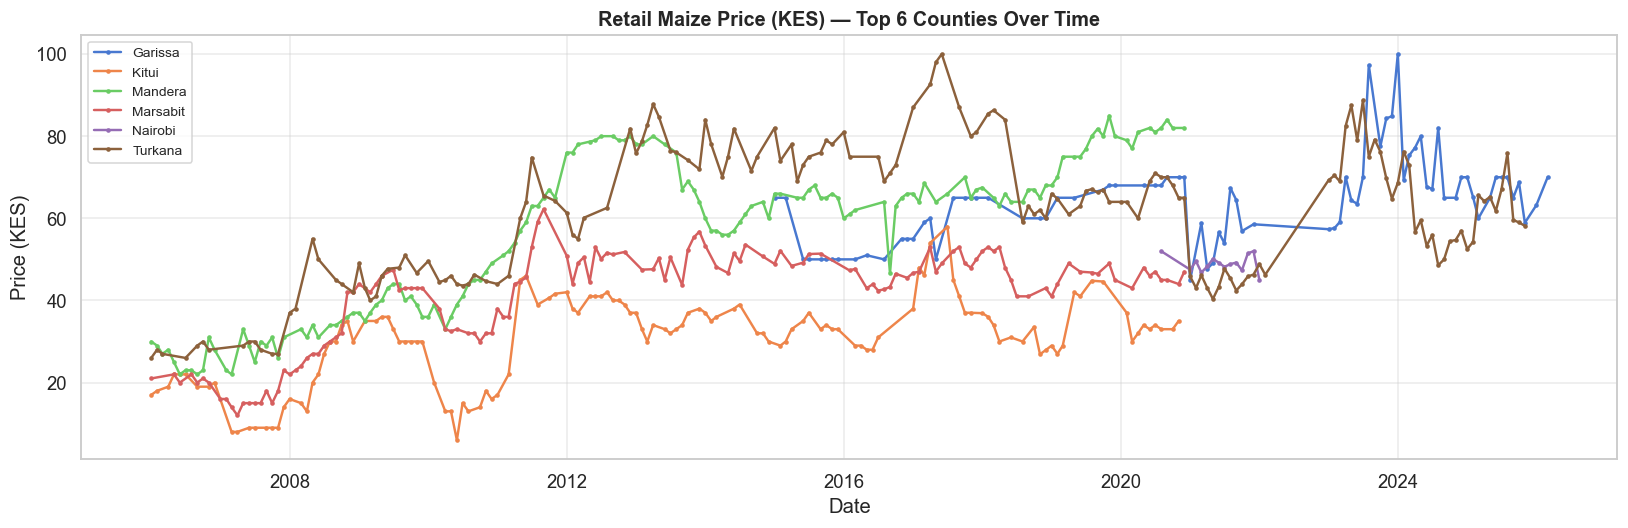

In [85]:
# Maize retail price over time 
maize = df[df['commodity'] == 'Maize'].copy()

top_counties = maize.groupby('county')['n_obs'].sum().nlargest(6).index.tolist()
maize_top = maize[maize['county'].isin(top_counties)]

fig, ax = plt.subplots(figsize=(15, 5))
for county, grp in maize_top.groupby('county'):
    ax.plot(grp['date_month'], grp['price'], label=county, lw=1.6, marker='o', ms=2)

ax.set_title('Retail Maize Price (KES) — Top 6 Counties Over Time', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (KES)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## 5.2. Maize Price vs. Rainfall — The "Mirror" Effect

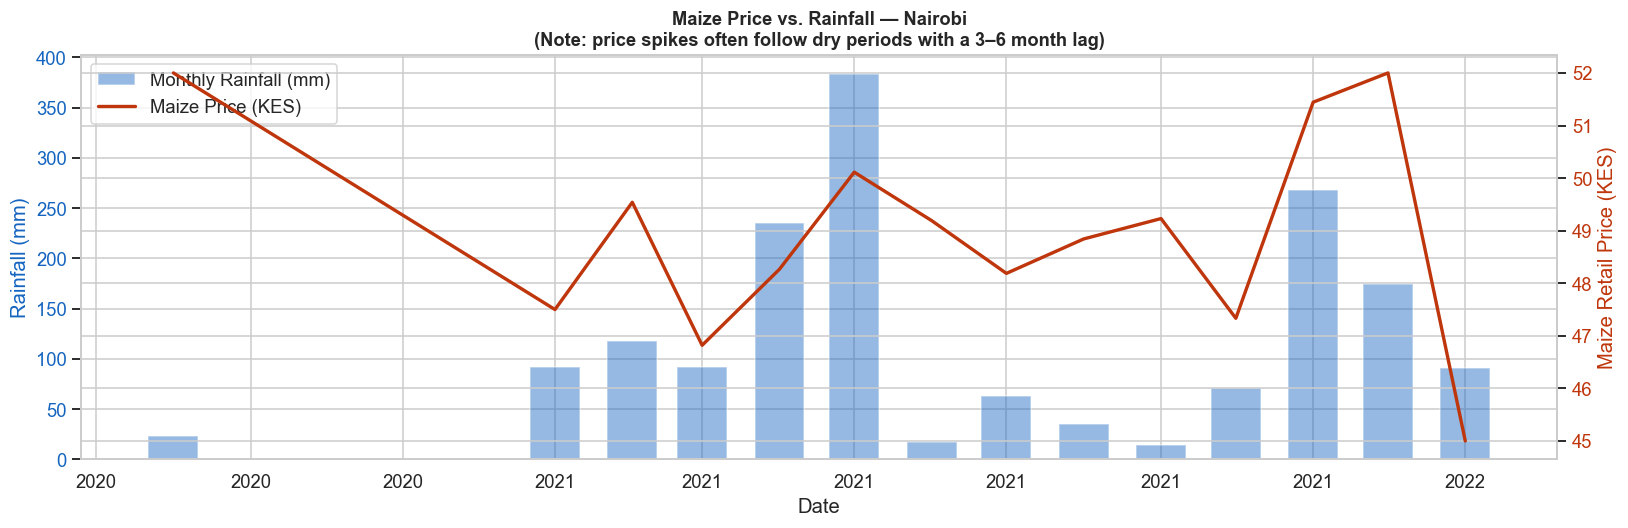

In [86]:
# Mirror effect: rainfall ↓ → price ↑ (with lag) 
focus_county = 'Nairobi'
subset = df[(df['county'] == focus_county) & (df['commodity'] == 'Maize')].dropna(subset=['price','rainfall_mm'])

fig, ax1 = plt.subplots(figsize=(15, 5))
color_rain  = '#1565C0'
color_price = '#BF360C'

ax1.bar(subset['date_month'], subset['rainfall_mm'], color=color_rain, alpha=0.45, label='Monthly Rainfall (mm)', width=20)
ax1.set_ylabel('Rainfall (mm)', color=color_rain)
ax1.tick_params(axis='y', labelcolor=color_rain)
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.plot(subset['date_month'], subset['price'], color=color_price, lw=2.2, label='Maize Price (KES)')
ax2.set_ylabel('Maize Retail Price (KES)', color=color_price)
ax2.tick_params(axis='y', labelcolor=color_price)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title(f'Maize Price vs. Rainfall — {focus_county}\n(Note: price spikes often follow dry periods with a 3–6 month lag)',
               fontsize=12, fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 5.3. Correlation Heatmap
Correlation heatmap: do fuel & rainfall correlate with price? 

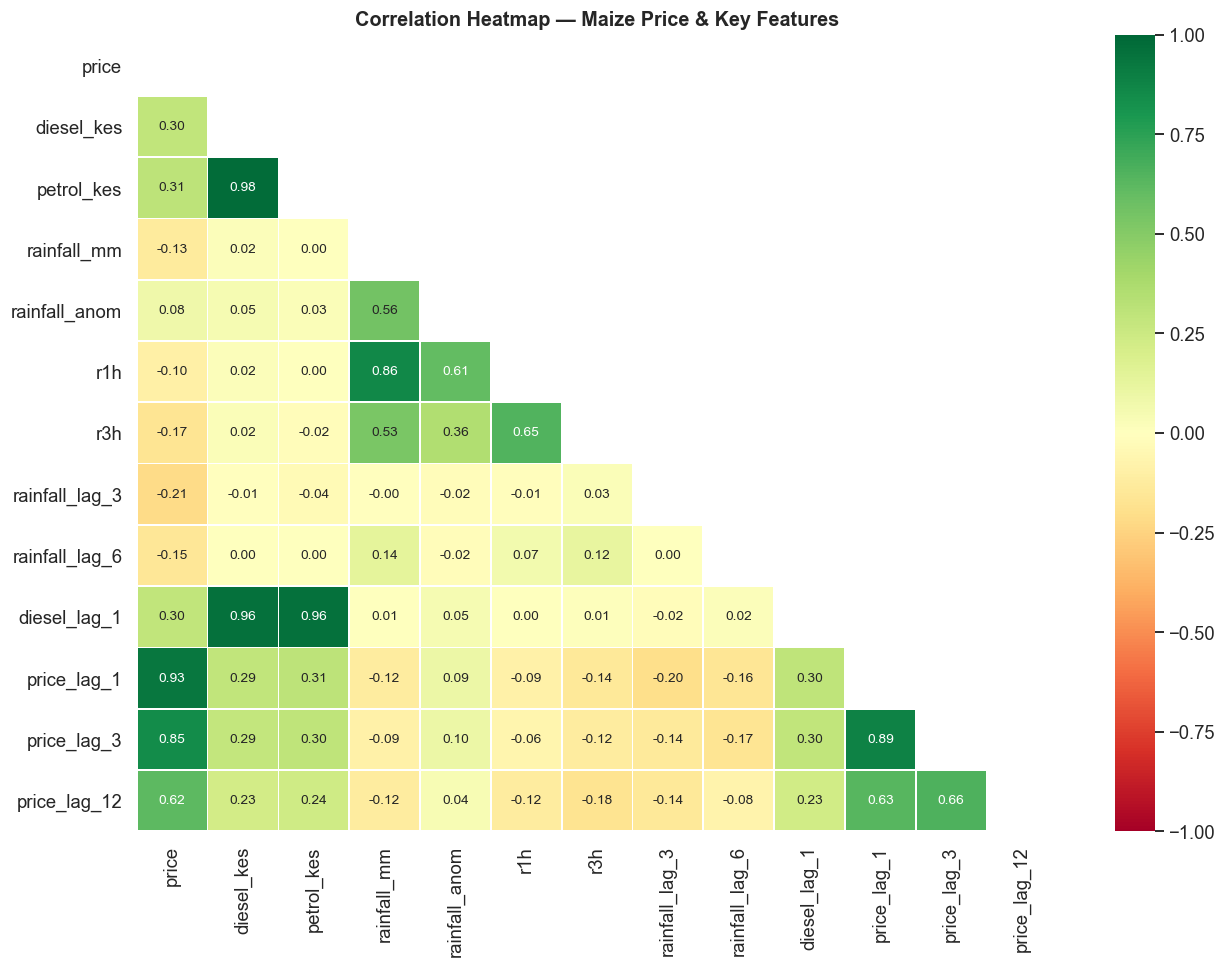


Correlation of each feature with Maize Price:
  price_lag_1               +0.935  ██████████████████
  price_lag_3               +0.849  ████████████████
  price_lag_12              +0.620  ████████████
  petrol_kes                +0.308  ██████
  diesel_kes                +0.297  █████
  diesel_lag_1              +0.296  █████
  rainfall_lag_3            -0.214  ████
  r3h                       -0.169  ███
  rainfall_lag_6            -0.155  ███
  rainfall_mm               -0.126  ██
  r1h                       -0.100  █
  rainfall_anom             +0.079  █


In [87]:
corr_cols = [
    'price', 'diesel_kes', 'petrol_kes',
    'rainfall_mm', 'rainfall_anom', 'r1h', 'r3h',
    'rainfall_lag_3', 'rainfall_lag_6',
    'diesel_lag_1', 'price_lag_1', 'price_lag_3', 'price_lag_12'
]

maize_corr = df[df['commodity'] == 'Maize'][corr_cols].dropna()
corr_matrix = maize_corr.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Correlation Heatmap — Maize Price & Key Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelation of each feature with Maize Price:')
corr_with_price = corr_matrix['price'].drop('price').sort_values(key=abs, ascending=False)
for feat, val in corr_with_price.items():
    bar = '█' * int(abs(val) * 20)
    sign = '+' if val > 0 else '-'
    print(f'  {feat:<25} {sign}{abs(val):.3f}  {bar}')

## 5.4. Retail vs. Wholesale — analysis
Retail vs Wholesale price comparison

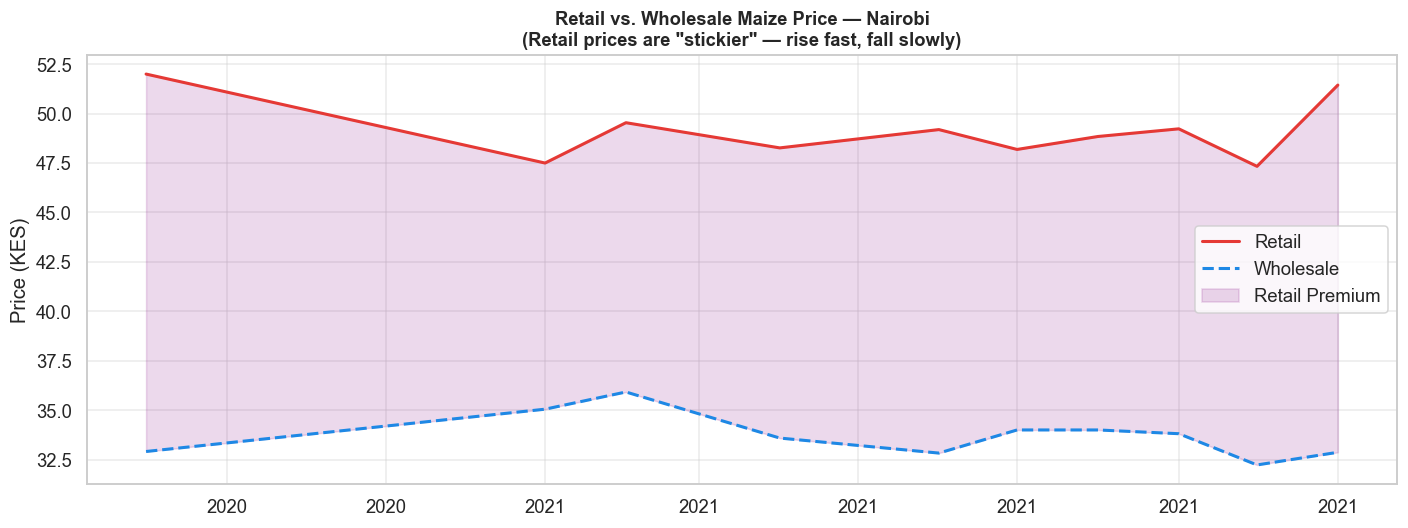

In [88]:
# Retail vs Wholesale price comparison 
all_prices = wfp[
    (wfp['commodity'].isin(KEY_COMMODITIES)) &
    (wfp['admin2'] == 'Nairobi')
].copy()
all_prices['date_month'] = all_prices['date'].dt.to_period('M').dt.to_timestamp()
all_prices['commodity_clean'] = all_prices['commodity'].map(commodity_map)

pivot = (
    all_prices[all_prices['commodity_clean'] == 'Maize']
    .groupby(['date_month', 'pricetype'])['price'].mean()
    .unstack('pricetype')
    .dropna()
)

if not pivot.empty:
    fig, ax = plt.subplots(figsize=(13, 5))
    if 'Retail' in pivot.columns:
        ax.plot(pivot.index, pivot['Retail'],    label='Retail',    color='#E53935', lw=2)
    if 'Wholesale' in pivot.columns:
        ax.plot(pivot.index, pivot['Wholesale'], label='Wholesale', color='#1E88E5', lw=2, ls='--')
    ax.fill_between(pivot.index,
                    pivot.get('Wholesale', pivot.iloc[:,0]),
                    pivot.get('Retail',    pivot.iloc[:,0]),
                    alpha=0.15, color='purple', label='Retail Premium')
    ax.set_title('Retail vs. Wholesale Maize Price — Nairobi\n(Retail prices are "stickier" — rise fast, fall slowly)',
                  fontsize=12, fontweight='bold')
    ax.set_ylabel('Price (KES)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend()
    ax.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough overlapping retail/wholesale data for Nairobi maize')

## 5.5. Commodity Price Seasonality
average monthly price of commodities

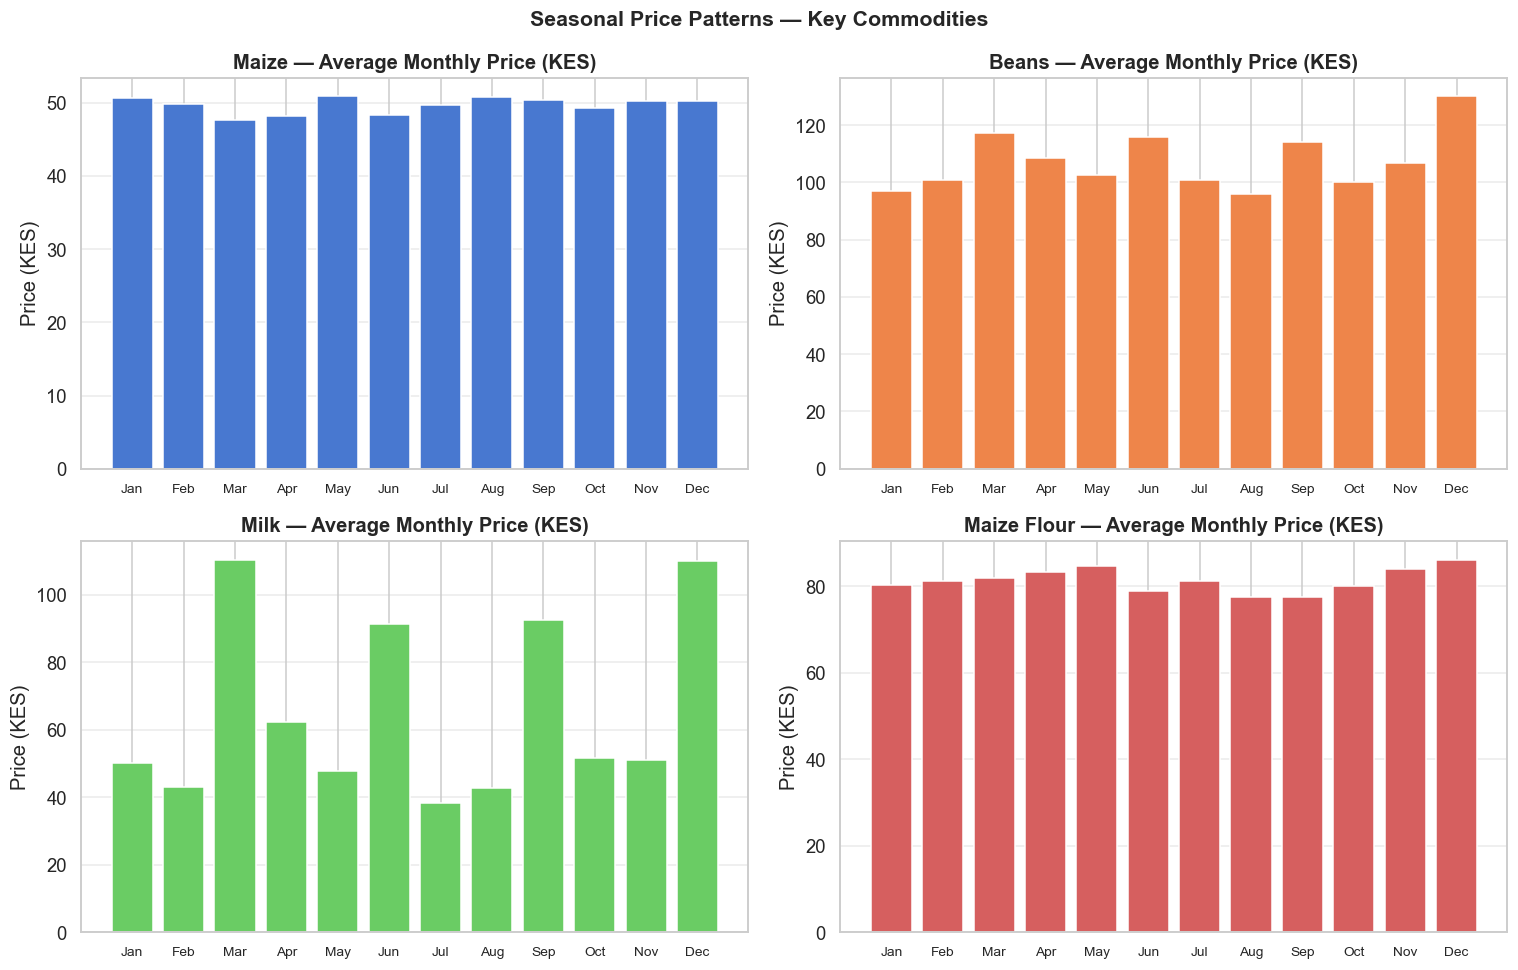

In [89]:
# Average price by calendar month (seasonality) 
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for i, commodity in enumerate(['Maize', 'Beans', 'Milk', 'Maize Flour']):
    sub = df[df['commodity'] == commodity].copy()
    if sub.empty:
        axes[i].set_title(f'{commodity} — No Data')
        continue
    seasonal = sub.groupby('month')['price'].mean()
    axes[i].bar(seasonal.index, seasonal.values, color=sns.color_palette('muted')[i], edgecolor='white')
    axes[i].set_title(f'{commodity} — Average Monthly Price (KES)', fontweight='bold')
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(month_labels, fontsize=9)
    axes[i].set_ylabel('Price (KES)')
    axes[i].grid(axis='y', alpha=0.4)

plt.suptitle('Seasonal Price Patterns — Key Commodities', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Key Patterns Observed:
Fuel-Driven Inflation: Maize prices track diesel costs closely (transport + production inputs).

Rainfall Mirror Effect: Low rainfall periods (especially lagged 3-6 months) precede major price spikes.

Seasonality: Prices tend to peak before harvest (Jan-Feb, Jul-Aug) and drop post-harvest if rains are good.

Stickiness: Wholesale prices respond faster to shocks than retail (as noted in workflow).

---
## 6. Modelling

### 6.1. Model Data Preparation

In [90]:
# Feature list for modelling 
FEATURE_COLS = [
    # Time features
    'year', 'month_sin', 'month_cos',
    # Rainfall features (lagged — delay in impact)
    'rainfall_lag_1', 'rainfall_lag_3', 'rainfall_lag_6',
    'rainfall_anom_lag_1', 'rainfall_anom_lag_3',
    # Fuel features (lagged)
    'diesel_lag_1', 'diesel_lag_2',
    # Autoregressive price features
    'price_lag_1', 'price_lag_3', 'price_lag_6', 'price_lag_12',
    'price_rolling_3',
    # Categorical encodings (added below)
    'county_enc', 'commodity_enc'
]

TARGET = 'price'

# Label-encode categoricals 
le_county    = LabelEncoder()
le_commodity = LabelEncoder()

df['county_enc']    = le_county.fit_transform(df['county'])
df['commodity_enc'] = le_commodity.fit_transform(df['commodity'])

# Drop rows with NaN in target or key lag features 
df_model = df.dropna(subset=[TARGET, 'price_lag_1', 'price_lag_3', 'diesel_lag_1']).copy()

X = df_model[FEATURE_COLS]
y = df_model[TARGET]

# Impute any remaining NaNs with column median
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)

print(f'Modelling dataset: {X_imp.shape[0]:,} rows × {X_imp.shape[1]} features')
print(f'Target: price — mean={y.mean():.1f} KES, std={y.std():.1f} KES')

Modelling dataset: 1,353 rows × 17 features
Target: price — mean=78.1 KES, std=36.6 KES


Temporal train/test split

In [91]:
# train/test split
# Use data before 2024 for training, 2024+ for testing
split_date = pd.Timestamp('2024-01-01')
train_mask = df_model['date_month'] < split_date
test_mask  = df_model['date_month'] >= split_date

X_train, X_test = X_imp[train_mask], X_imp[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f'Training set:  {X_train.shape[0]:,} rows  ({df_model[train_mask]["date_month"].min().date()} → {df_model[train_mask]["date_month"].max().date()})')
print(f'Test set:      {X_test.shape[0]:,} rows  ({df_model[test_mask]["date_month"].min().date()} → {df_model[test_mask]["date_month"].max().date()})')

Training set:  1,059 rows  (2010-02-01 → 2023-12-01)
Test set:      294 rows  (2024-01-01 → 2026-03-01)


### 6.2. Baseline — Linear Regression

In [92]:
#  Baseline: Linear Regression 
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print('━' * 45)
print(' BASELINE: Linear Regression')
print('━' * 45)
print(f'  MAE  : {mae_lr:.2f} KES')
print(f'  RMSE : {rmse_lr:.2f} KES')
print(f'  R²   : {r2_lr:.4f}')
print('━' * 45)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 BASELINE: Linear Regression
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : 12.63 KES
  RMSE : 18.07 KES
  R²   : 0.7527
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 6.3. Random Forest Regressor

In [102]:
# Random Forest 
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print('━' * 45)
print(' Random Forest Regressor')
print('━' * 45)
print(f'  MAE  : {mae_rf:.2f} KES')
print(f'  RMSE : {rmse_rf:.2f} KES')
print(f'  R²   : {r2_rf:.4f}')
print('━' * 45)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Random Forest Regressor
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : 17.72 KES
  RMSE : 25.42 KES
  R²   : 0.5102
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 6.4. Gradient Boosting Regressor (XGBoost-equivalent)

In [103]:
# Gradient Boosting (mirrors XGBoost logic) 
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=5,
    min_samples_leaf=4,
    subsample=0.85,
    random_state=42
)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

mae_gbr  = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr   = r2_score(y_test, y_pred_gbr)

print('━' * 45)
print('🚀 Gradient Boosting Regressor')
print('━' * 45)
print(f'  MAE  : {mae_gbr:.2f} KES')
print(f'  RMSE : {rmse_gbr:.2f} KES')
print(f'  R²   : {r2_gbr:.4f}')
print('━' * 45)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🚀 Gradient Boosting Regressor
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : 18.96 KES
  RMSE : 26.44 KES
  R²   : 0.4704
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
#  7. Models Evaluation

## 7.1 . Model Comparison Summary

In [104]:
# Side-by-side comparison 
results = pd.DataFrame({
    'Model': ['Linear Regression (Baseline)', 'Random Forest', 'Gradient Boosting'],
    'MAE (KES)':  [mae_lr,  mae_rf,  mae_gbr],
    'RMSE (KES)': [rmse_lr, rmse_rf, rmse_gbr],
    'R²':         [r2_lr,   r2_rf,   r2_gbr]
})

print(' MODEL PERFORMANCE SUMMARY')
print('=' * 60)
print(results.to_string(index=False, float_format='{:.2f}'.format))
print('=' * 60)

best_model = results.loc[results['MAE (KES)'].idxmin(), 'Model']
print(f' Best Model (lowest MAE): {best_model}')

 MODEL PERFORMANCE SUMMARY
                        Model  MAE (KES)  RMSE (KES)   R²
 Linear Regression (Baseline)      12.63       18.07 0.75
                Random Forest      17.72       25.42 0.51
            Gradient Boosting      18.96       26.44 0.47
 Best Model (lowest MAE): Linear Regression (Baseline)


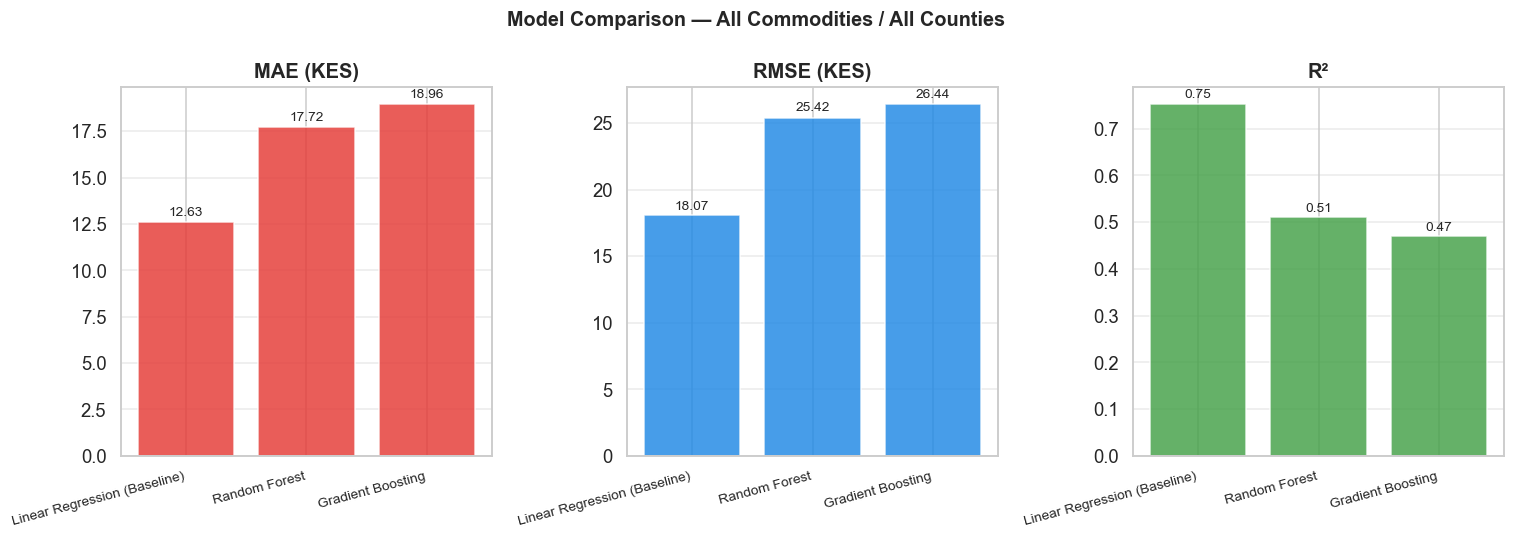

In [105]:
# Bar chart comparison 
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['MAE (KES)', 'RMSE (KES)', 'R²']
colors  = ['#E53935', '#1E88E5', '#43A047']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(results['Model'], results[metric], color=color, alpha=0.82, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_xticklabels(results['Model'], rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Model Comparison — All Commodities / All Counties', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7.2. K-Fold Cross-Validation (Best Model)

In [106]:
# K-Fold CV on best model (GBR) 
kf = KFold(n_splits=5, shuffle=False)   # No shuffle — time-series ordering preserved

cv_mae  = -cross_val_score(gbr, X_imp, y, cv=kf, scoring='neg_mean_absolute_error')
cv_rmse = np.sqrt(-cross_val_score(gbr, X_imp, y, cv=kf, scoring='neg_mean_squared_error'))

print('━' * 50)
print('7-Fold Cross-Validation — Gradient Boosting')
print('━' * 50)
for i, (mae_i, rmse_i) in enumerate(zip(cv_mae, cv_rmse), 1):
    print(f'  Fold {i}:  MAE = {mae_i:7.2f} KES  |  RMSE = {rmse_i:7.2f} KES')
print('━' * 50)
print(f'  Mean:   MAE = {cv_mae.mean():7.2f} KES  |  RMSE = {cv_rmse.mean():7.2f} KES')
print(f'  Std:    MAE = {cv_mae.std():7.2f} KES  |  RMSE = {cv_rmse.std():7.2f} KES')
print('━' * 50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
7-Fold Cross-Validation — Gradient Boosting
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Fold 1:  MAE =    8.72 KES  |  RMSE =   14.31 KES
  Fold 2:  MAE =    6.80 KES  |  RMSE =   10.45 KES
  Fold 3:  MAE =    5.15 KES  |  RMSE =    9.08 KES
  Fold 4:  MAE =    6.07 KES  |  RMSE =    9.89 KES
  Fold 5:  MAE =    7.56 KES  |  RMSE =   11.86 KES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean:   MAE =    6.86 KES  |  RMSE =   11.12 KES
  Std:    MAE =    1.23 KES  |  RMSE =    1.84 KES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 7.3. Feature Importance

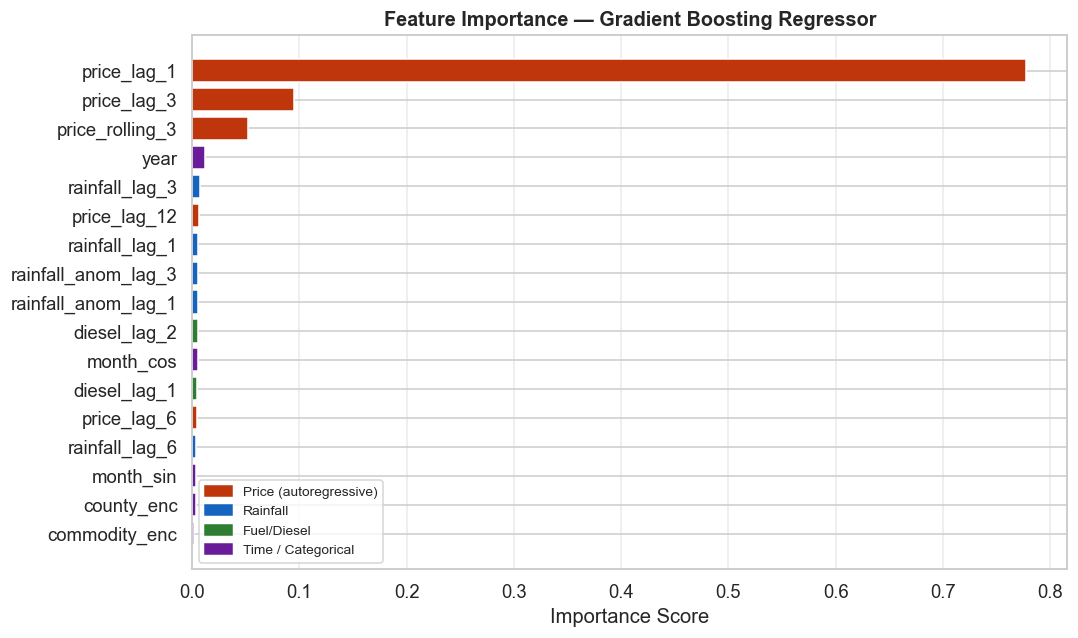

In [107]:
# Feature importance from GBR 
feat_imp = pd.Series(gbr.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = ['#BF360C' if 'price' in f else '#1565C0' if 'rainfall' in f else
              '#2E7D32' if 'diesel' in f else '#6A1B9A' for f in feat_imp.index]
bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors_fi[::-1], edgecolor='white')
ax.set_title('Feature Importance — Gradient Boosting Regressor', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color='#BF360C', label='Price (autoregressive)'),
    Patch(color='#1565C0', label='Rainfall'),
    Patch(color='#2E7D32', label='Fuel/Diesel'),
    Patch(color='#6A1B9A', label='Time / Categorical'),
]
ax.legend(handles=legend, fontsize=9)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

## 7.4. Predicted vs. Actual — Visual Check

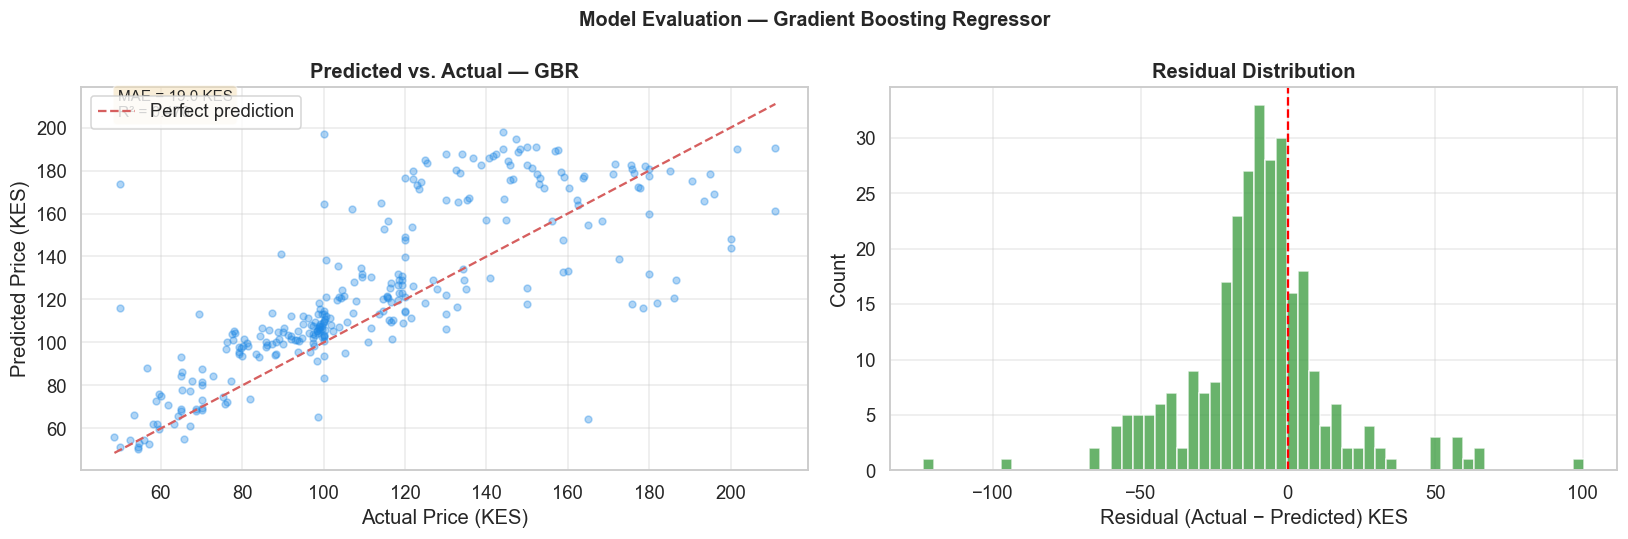

In [108]:
# Predicted vs Actual scatter & time-series 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter
axes[0].scatter(y_test, y_pred_gbr, alpha=0.35, s=20, color='#1E88E5')
lims = [min(y_test.min(), y_pred_gbr.min()), max(y_test.max(), y_pred_gbr.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (KES)')
axes[0].set_ylabel('Predicted Price (KES)')
axes[0].set_title('Predicted vs. Actual — GBR', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.4)
axes[0].text(0.05, 0.92, f'MAE = {mae_gbr:.1f} KES\nR² = {r2_gbr:.3f}',
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Residuals
residuals = y_test.values - y_pred_gbr
axes[1].hist(residuals, bins=60, color='#43A047', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', lw=1.5, ls='--')
axes[1].set_xlabel('Residual (Actual − Predicted) KES')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].grid(alpha=0.4)

plt.suptitle('Model Evaluation — Gradient Boosting Regressor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

No Maize/Nairobi data in test period — showing overall test predictions


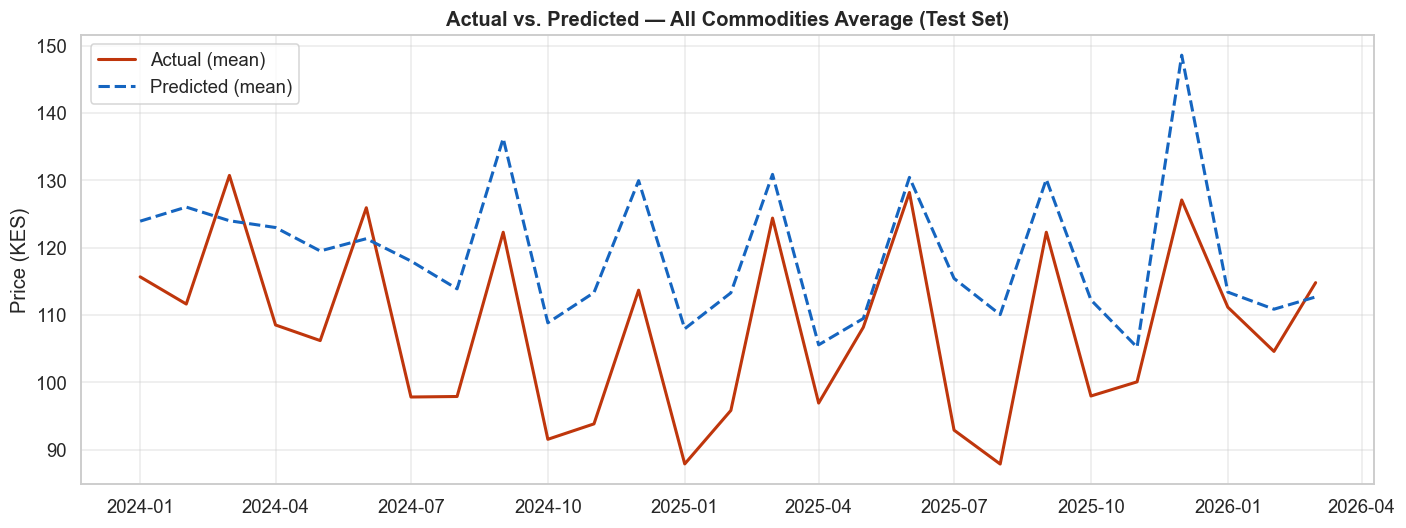

In [109]:
# Time-series: Actual vs Predicted for Maize / Nairobi 
test_df = df_model[test_mask].copy()
test_df['predicted'] = y_pred_gbr

maize_nairobi_test = test_df[
    (test_df['commodity'] == 'Maize') &
    (test_df['county'] == 'Nairobi')
].sort_values('date_month')

if not maize_nairobi_test.empty:
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(maize_nairobi_test['date_month'], maize_nairobi_test['price'],     'o-', lw=2,   label='Actual',    color='#BF360C')
    ax.plot(maize_nairobi_test['date_month'], maize_nairobi_test['predicted'], 's--', lw=2,  label='Predicted', color='#1565C0')
    ax.fill_between(maize_nairobi_test['date_month'],
                    maize_nairobi_test['price'],
                    maize_nairobi_test['predicted'],
                    alpha=0.15, color='grey')
    ax.set_title('Actual vs. Predicted — Maize Retail Price, Nairobi (2024–2026)', fontweight='bold')
    ax.set_ylabel('Price (KES)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.legend()
    ax.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print('No Maize/Nairobi data in test period — showing overall test predictions')
    # Fallback: sample of all test predictions
    sample = test_df.groupby('date_month')[['price','predicted']].mean().reset_index()
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(sample['date_month'], sample['price'],     lw=2, label='Actual (mean)',    color='#BF360C')
    ax.plot(sample['date_month'], sample['predicted'], lw=2, label='Predicted (mean)', color='#1565C0', ls='--')
    ax.set_title('Actual vs. Predicted — All Commodities Average (Test Set)', fontweight='bold')
    ax.set_ylabel('Price (KES)')
    ax.legend()
    ax.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

## 7.5. Commodity Error Breakdown
MAE broken down by commodity

In [110]:
# MAE broken down by commodity 
test_df['abs_error'] = (test_df['price'] - test_df['predicted']).abs()

commodity_metrics = (
    test_df.groupby('commodity')
    .apply(lambda g: pd.Series({
        'MAE (KES)':     mean_absolute_error(g['price'], g['predicted']),
        'RMSE (KES)':    np.sqrt(mean_squared_error(g['price'], g['predicted'])),
        'R²':            r2_score(g['price'], g['predicted']) if len(g) > 2 else np.nan,
        'N':             len(g),
        'Mean Price':    g['price'].mean()
    }))
    .reset_index()
)
commodity_metrics['MAE % of Price'] = (commodity_metrics['MAE (KES)'] / commodity_metrics['Mean Price'] * 100).round(1)

print('Per-Commodity Model Performance')
print('=' * 75)
print(commodity_metrics.to_string(index=False, float_format='{:.2f}'.format))

Per-Commodity Model Performance
   commodity  MAE (KES)  RMSE (KES)    R²     N  Mean Price  MAE % of Price
       Beans      28.31       34.26 -1.22 74.00      146.54           19.30
       Maize       9.04       12.79 -0.85 46.00       65.34           13.80
 Maize Flour      12.54       14.56 -1.82 49.00       91.03           13.80
        Milk      30.89       41.46 -0.54 43.00      150.41           20.50
 Wheat Flour      13.67       18.07 -1.02 82.00      102.94           13.30
